# 03 — Exploratory Data Analysis for Sleep-Stage Structure

**Purpose:** Verify that the prepared dataset has the expected class structure, signal characteristics, artifact burden, and temporal dependencies before model training.

This notebook is explanatory evidence for the exhibition. It does **not** create alternative performance results.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram

CACHE_DIR = Path("/home/shamique/projects/sleep/data/cache")
STAGE_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CHANNEL_NAMES = ["EEG Fpz-Cz", "EEG Pz-Oz", "EOG horizontal", "EMG submental"]

cache_index = pd.read_csv(CACHE_DIR / "cache_index.csv")
display(cache_index.head())


,subject_id,night,split,n_epochs,n_flagged,cache_path
0,SC4001,0,train,2650,2580,/home/shamique/projects/sleep/data/cache/SC400...
1,SC4002,0,train,2829,2424,/home/shamique/projects/sleep/data/cache/SC400...
2,SC4011,0,train,2802,2705,/home/shamique/projects/sleep/data/cache/SC401...
3,SC4012,0,train,2848,2637,/home/shamique/projects/sleep/data/cache/SC401...


## 1. Sleep-stage class distribution

Class imbalance is expected in Sleep-EDF and is one reason the training pipeline uses imbalance-aware supervision.


,stage,epochs,percentage
0,Wake,7562,67.948603
1,N1,318,2.857400
2,N2,1845,16.578309
3,N3,718,6.451613
4,REM,686,6.164076


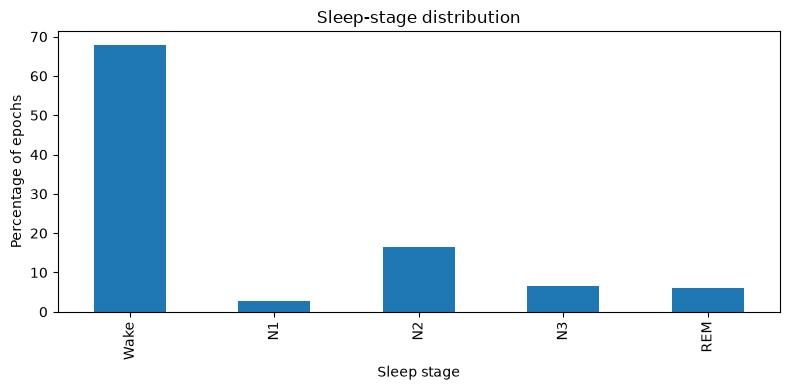

In [2]:
all_labels = []
record_counts = []

for _, row in cache_index.iterrows():
    d = np.load(row["cache_path"])
    labels = d["labels"]
    all_labels.append(labels)
    counts = np.bincount(labels, minlength=5)
    record_counts.append({
        "subject_id": row["subject_id"],
        "night": row["night"],
        **{STAGE_NAMES[i]: int(counts[i]) for i in range(5)}
    })

all_labels = np.concatenate(all_labels)
overall_counts = np.bincount(all_labels, minlength=5)

distribution = pd.DataFrame({
    "stage": STAGE_NAMES,
    "epochs": overall_counts,
    "percentage": overall_counts / overall_counts.sum() * 100,
})
display(distribution)

ax = distribution.plot.bar(x="stage", y="percentage", legend=False, figsize=(8,4))
ax.set_ylabel("Percentage of epochs")
ax.set_xlabel("Sleep stage")
ax.set_title("Sleep-stage distribution")
plt.tight_layout()
plt.show()


## 2. Artifact/QC prevalence

The notebook reports the observed QC flag burden without silently discarding evidence.


In [3]:
flag_rows = []

for _, row in cache_index.iterrows():
    d = np.load(row["cache_path"])
    flag_rows.append({
        "subject_id": row["subject_id"],
        "night": row["night"],
        "epochs": len(d["labels"]),
        "flag_rate": float(d["qc_flag"].mean()),
    })

flag_df = pd.DataFrame(flag_rows).sort_values("flag_rate", ascending=False)
display(flag_df)

weighted_flag_rate = (
    sum(np.load(row["cache_path"])["qc_flag"].sum() for _, row in cache_index.iterrows())
    / max(sum(np.load(row["cache_path"])["labels"].size for _, row in cache_index.iterrows()), 1)
)

print(f"Epoch-weighted QC flag rate: {weighted_flag_rate:.2%}")


,subject_id,night,epochs,flag_rate
0,SC4001,0,2650,0.973585
2,SC4011,0,2802,0.965382
3,SC4012,0,2848,0.925913
1,SC4002,0,2829,0.856840


Epoch-weighted QC flag rate: 92.96%


## 3. Representative signals by sleep stage


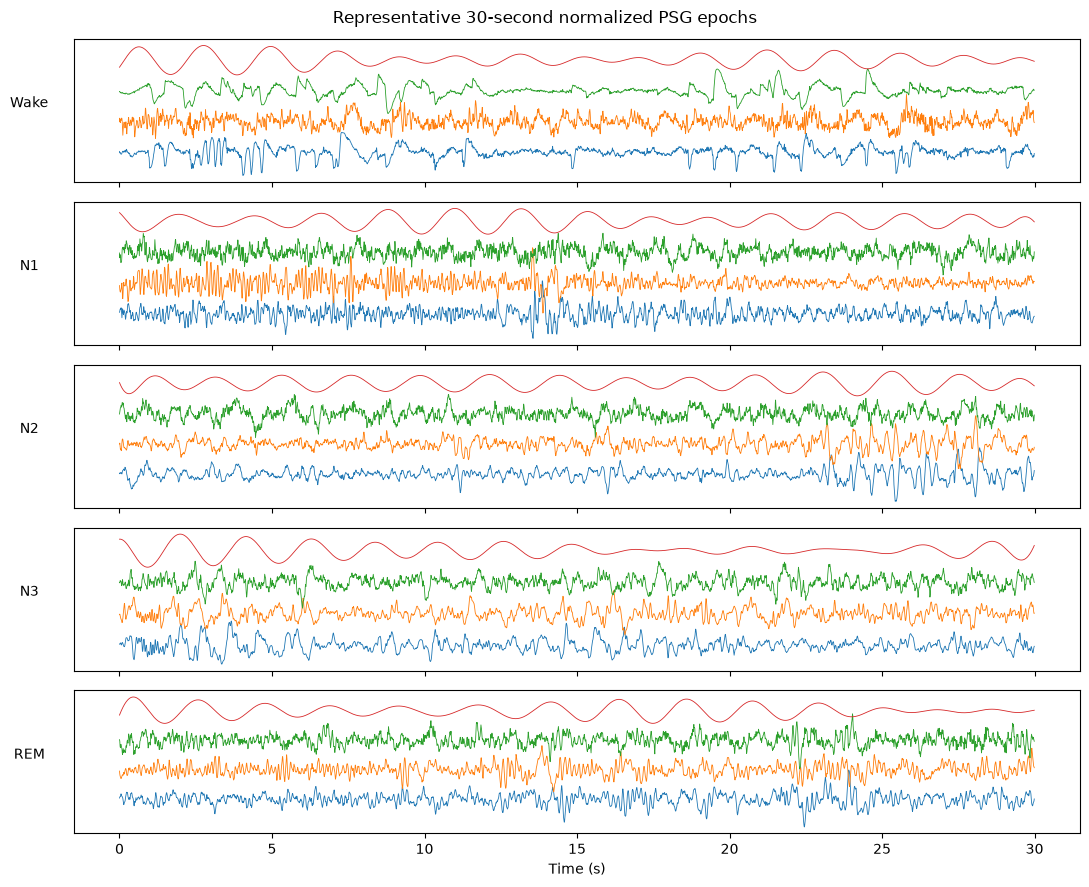

In [4]:
sample = np.load(cache_index.iloc[0]["cache_path"])
epochs = sample["epochs"]
labels = sample["labels"]
fs = int(round(float(sample["fs"])))

fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)

for stage, ax in enumerate(axes):
    indices = np.where(labels == stage)[0]
    if len(indices) == 0:
        ax.set_visible(False)
        continue

    epoch = epochs[indices[0]]
    t = np.arange(epoch.shape[-1]) / fs

    for ch in range(epoch.shape[0]):
        ax.plot(t, epoch[ch] + ch * 5, linewidth=0.6)

    ax.set_ylabel(STAGE_NAMES[stage], rotation=0, labelpad=32)
    ax.set_yticks([])

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Representative 30-second normalized PSG epochs")
plt.tight_layout()
plt.show()


## 4. EEG band-power fingerprint


,delta,theta,alpha,beta
stage,,,,
Wake,0.650991,0.091830,0.027180,0.046369
N1,0.531568,0.205676,0.061045,0.046518
N2,0.723051,0.107664,0.027503,0.015515
N3,0.770282,0.059690,0.016855,0.005772
REM,0.522352,0.237569,0.058404,0.030799


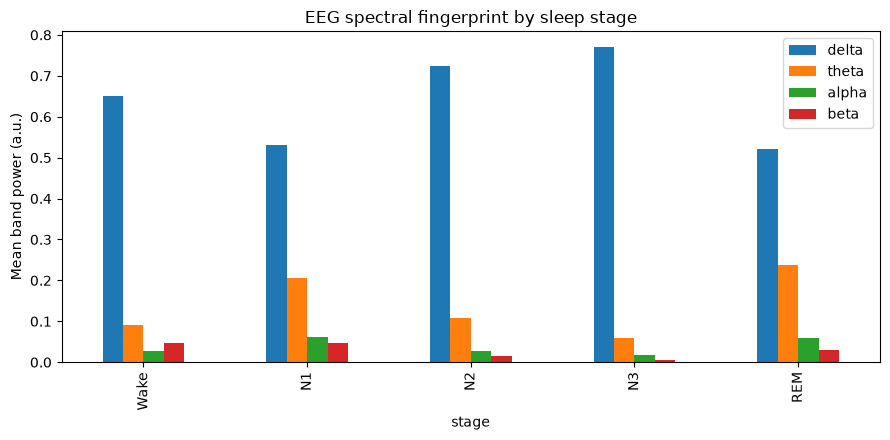

In [5]:
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}

def band_power(signal, fs, bands):
    f, pxx = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    values = {}
    for name, (lo, hi) in bands.items():
        mask = (f >= lo) & (f < hi)
        values[name] = float(np.trapezoid(pxx[mask], f[mask]))
    return values

rows = []
for stage in range(5):
    indices = np.where(labels == stage)[0]
    for idx in indices[: min(50, len(indices))]:
        bp = band_power(epochs[idx, 0], fs, BANDS)
        rows.append({"stage": STAGE_NAMES[stage], **bp})

band_df = pd.DataFrame(rows)
band_summary = band_df.groupby("stage")[list(BANDS)].mean().loc[STAGE_NAMES]
display(band_summary)

band_summary.plot.bar(figsize=(9, 4.5))
plt.ylabel("Mean band power (a.u.)")
plt.title("EEG spectral fingerprint by sleep stage")
plt.tight_layout()
plt.show()


## 5. Hypnogram and spectrogram

The combination demonstrates why the task is naturally sequential: physiological structure changes across time and sleep stages form a temporal trajectory.


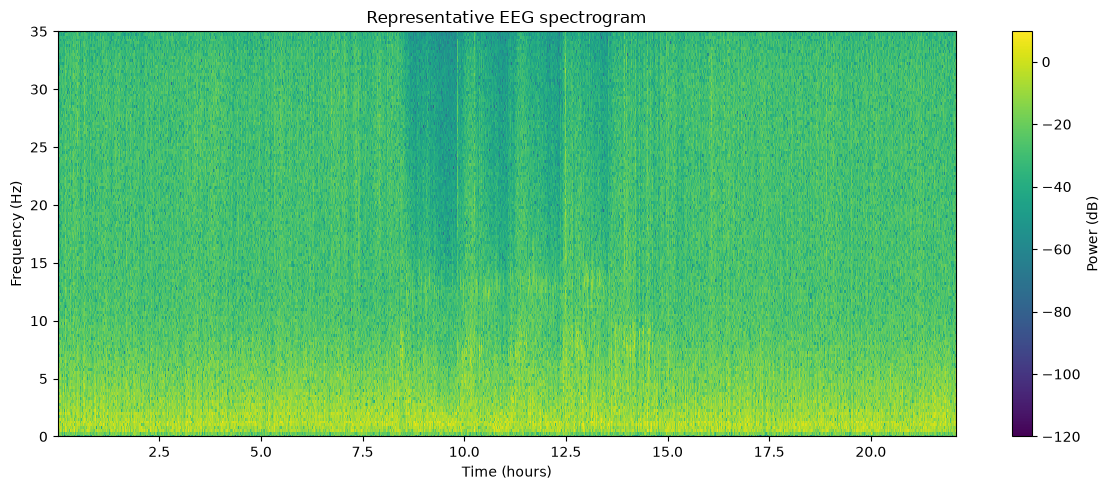

In [6]:
full_signal = epochs[:, 0, :].reshape(-1)

f, t, Sxx = spectrogram(
    full_signal,
    fs=fs,
    nperseg=fs * 4,
    noverlap=fs * 2,
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(
    t / 3600,
    f,
    10 * np.log10(Sxx + 1e-12),
    shading="auto",
)
ax.set_ylim(0, 35)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Representative EEG spectrogram")
fig.colorbar(im, ax=ax, label="Power (dB)")
plt.tight_layout()
plt.show()


## 6. Stage-transition structure

The final model uses ten contiguous epochs because sleep-stage labels exhibit strong temporal continuity.


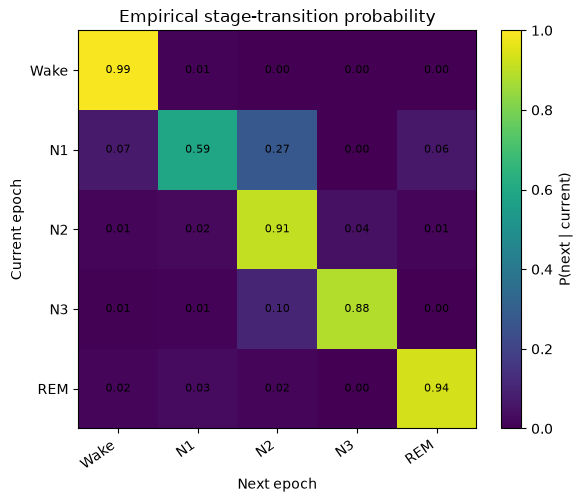

Mean diagonal/self-transition probability: 86.11%


In [7]:
transition = np.zeros((5, 5), dtype=np.int64)

for _, row in cache_index.iterrows():
    labs = np.load(row["cache_path"])["labels"]
    for current_stage, next_stage in zip(labs[:-1], labs[1:]):
        transition[current_stage, next_stage] += 1

transition_prob = transition / transition.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transition_prob, vmin=0, vmax=1)
ax.set_xticks(range(5), STAGE_NAMES, rotation=35, ha="right")
ax.set_yticks(range(5), STAGE_NAMES)
ax.set_xlabel("Next epoch")
ax.set_ylabel("Current epoch")
ax.set_title("Empirical stage-transition probability")

for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{transition_prob[i,j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="P(next | current)")
plt.tight_layout()
plt.show()

print(f"Mean diagonal/self-transition probability: {np.diag(transition_prob).mean():.2%}")


## 7. Modeling conclusions

The EDA supports the final architecture from three directions:

1. **Multi-scale waveform structure** motivates the multi-resolution convolutional stem.
2. **Spectral differences between stages** motivate the Gabor-inspired feature extraction block.
3. **Temporal continuity between adjacent epochs** motivates the 2-layer GRU and 10-epoch context window.

These are architecture motivations, not additional performance claims.
